### Importing Modules

In [12]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics

data = pd.read_csv("retail_demand.csv")
data.head()

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold
0,1,8222,Chennai,Summer,Heater,1849.0363,2117.0487,12
1,2,8222,Bangalore,Monsoon,Heater,1336.9121,1534.1589,26
2,3,8058,Kolkata,Winter,Heater,2320.4793,2631.3738,220
3,4,8091,Chennai,Winter,Raincoat,173.1042,202.8265,51
4,5,8512,Chennai,Autumn,Umbrella,244.9977,245.6155,77


### Data Preprocessing

In [13]:
#The Data Contains Missing values
data.isnull().sum()

ID             0
Store ID       0
Location       0
Season         0
Product        0
Total Price    1
Base Price     0
Units Sold     0
dtype: int64

In [14]:
data = data.dropna()

In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Location'] = le.fit_transform(data['Location'])
data['Season']   = le.fit_transform(data['Season'])
data['Product']  = le.fit_transform(data['Product'])

### Visualising the dataset

In [16]:
fig = px.scatter(data, x="Units Sold", y="Total Price",size='Units Sold')
fig.show()

In [17]:
print(data.corr(numeric_only=True))

                   ID  Store ID  Location    Season   Product  Total Price  \
ID           1.000000  0.002290  0.004905 -0.006169 -0.000539    -0.000603   
Store ID     0.002290  1.000000  0.000781 -0.000389  0.000549     0.002237   
Location     0.004905  0.000781  1.000000  0.000060 -0.004099    -0.004749   
Season      -0.006169 -0.000389  0.000060  1.000000  0.000201    -0.004216   
Product     -0.000539  0.000549 -0.004099  0.000201  1.000000    -0.300912   
Total Price -0.000603  0.002237 -0.004749 -0.004216 -0.300912     1.000000   
Base Price  -0.000551  0.002393 -0.004602 -0.004127 -0.301464     0.998122   
Units Sold   0.000163  0.005909 -0.006192  0.046134  0.019419    -0.027537   

             Base Price  Units Sold  
ID            -0.000551    0.000163  
Store ID       0.002393    0.005909  
Location      -0.004602   -0.006192  
Season        -0.004127    0.046134  
Product       -0.301464    0.019419  
Total Price    0.998122   -0.027537  
Base Price     1.000000   -0.02

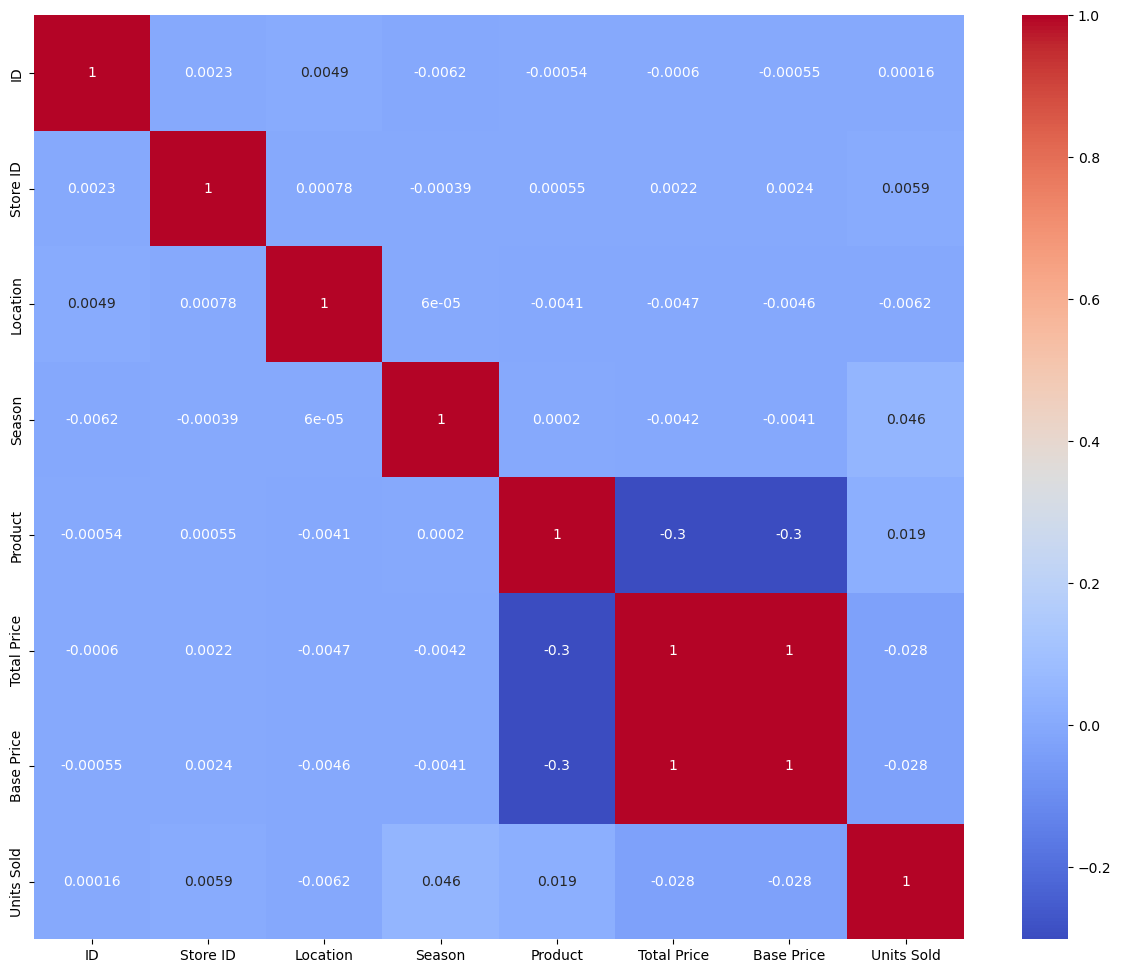

In [18]:
correlations = data.corr(numeric_only=True)
plt.figure(figsize=(15, 12))
sns.heatmap(correlations, cmap="coolwarm", annot=True)
plt.show()

## Model Training

In [19]:
# Define the features (X) and target variable (y)
X = data[['Store ID', 'Location', 'Season', 'Product', 'Total Price', 'Base Price']]
y = data['Units Sold']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
feature_names = X.columns
# Create and train a linear regression model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

### Metrics for Accuracy Check

In [20]:
y_pred = model.predict(X_test)
# Calculate the Mean Squared Error (MSE) to evaluate the model
print('R2:',metrics.r2_score(y_test,y_pred))
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))


R2: 0.9646117986031563
MAE: 11.16073926073926
MSE: 223.8984681984682
RMSE: 14.96323722322373


### Visualizing Predictions

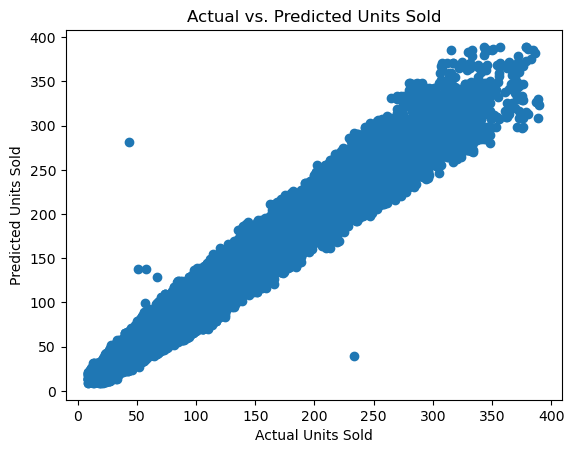

In [21]:
# Visualize the predictions
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.title('Actual vs. Predicted Units Sold')
plt.show()